In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

### Merge Data

In [ ]:
files = [file for file in os.listdir("./sales_data") if file.startswith("sales_")]

# Collect the frames first and concat once. Growing a DataFrame in a loop is
# O(n^2), and concatenating onto an empty DataFrame is deprecated behaviour.
frames = [pd.read_csv("./sales_data/" + file) for file in files]
all_data = pd.concat(frames, ignore_index=True)

all_data.head()

### Clean Up Data

In [3]:
# Find NAN
nan_df = all_data[all_data.isna().any(axis=1)]
# display(nan_df.head())

all_data = all_data.dropna(how="all")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


### Add & Change Data Type

In [ ]:
# Clean up some data - drop the repeated header rows
all_data = all_data[all_data["Order Date"].str[0:5] != "Order"]

# Parse the dates once, with an explicit format (much faster, and it fails
# loudly instead of guessing if a row is malformed)
order_dates = pd.to_datetime(all_data["Order Date"], format="%m/%d/%y %H:%M")

all_data["Month"] = order_dates.dt.month
all_data["Hour"] = order_dates.dt.hour
all_data["Minute"] = order_dates.dt.minute

# Convert column to number
all_data["Quantity Ordered"] = pd.to_numeric(all_data["Quantity Ordered"])
all_data["Price Each"] = pd.to_numeric(all_data["Price Each"])

# Add city data from Purchase Address
def get_city(address):
    return address.split(",")[1].strip(" ")

def get_state(address):
    return address.split(",")[2].split(" ")[1]

all_data["City"] = all_data["Purchase Address"].apply(lambda x: f"{get_city(x)} ({get_state(x)})")

# Add Sales data
all_data["Sales"] = all_data["Quantity Ordered"] * all_data["Price Each"]

# Export Data to csv
all_data.to_csv("./sales_data/all_sales_2019.csv", index=False)

### Read Cleaned Data

In [5]:
all_data = pd.read_csv("./sales_data/all_sales_2019.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,Minute,City,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,8,46,Dallas (TX),23.90
1,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,22,30,Boston (MA),99.99
2,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,14,38,Los Angeles (CA),600.00
3,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,14,38,Los Angeles (CA),11.99
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,9,27,Los Angeles (CA),11.99


### Q1: What was the best month for Sales?

In [ ]:
result = all_data[["Month", "Quantity Ordered", "Sales"]].groupby(["Month"]).sum()

# Take the months from the data instead of hard-coding range(1, 13) - the
# chart then still works if only part of the year is loaded
months = result.index.tolist()

plt.figure(figsize=(8,5), dpi=80)

plt.title("Sales Data 2019", fontdict={"fontname":"Calibri", "fontsize":20})

colors = ["#F4B084", "#A9D08E", "#9BC2E6", "#FFD966"]

plt.bar(months, result["Sales"], color=colors[1])

plt.xlabel("Months")
plt.ylabel("Sales in USD ($)")

plt.xticks(months)
# Label the y axis in millions, scaled to whatever the data actually reaches
top = int(result["Sales"].max() // 1_000_000) + 1
plt.yticks([i*1_000_000 for i in range(1, top+1)], [f"{i}M" for i in range(1, top+1)])

plt.show()

### Q2: What city has the highest Sales

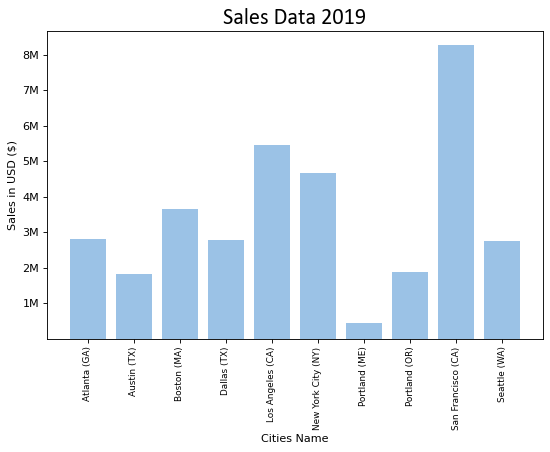

In [7]:
result = all_data[["City", "Quantity Ordered", "Sales"]].groupby(["City"]).sum()

cities = [city for city, df in all_data.groupby("City")]
sales = [i*1000000 for i in range(1,9)]
annot = [str(j) + "M" for j in range(1,9)]

plt.figure(figsize=(8,5), dpi=80)

plt.title("Sales Data 2019", fontdict={"fontname":"Calibri", "fontsize":20})

colors = ["#F4B084", "#A9D08E", "#9BC2E6", "#FFD966"]

plt.bar(cities, result["Sales"], color=colors[2])

plt.xlabel("Cities Name")
plt.ylabel("Sales in USD ($)")

plt.xticks(cities, rotation="vertical", size=8)
plt.yticks(sales, annot)

plt.show()

### Q3: What time should we display advertisements?

In [ ]:
# Order count per hour - count one column, not the whole frame
result = all_data.groupby("Hour")["Order ID"].count()

plt.figure(figsize=(8,5), dpi=80)

plt.title("Orders by Hour 2019", fontdict={"fontname":"Calibri", "fontsize":20})

plt.plot(result.index, result.values, color="red", linewidth=1, marker=".", linestyle="-")

plt.xlabel("Hours")
plt.ylabel("Number of Order")

plt.xticks(result.index)

plt.grid()
plt.show()

### Q4: What product sold the most?

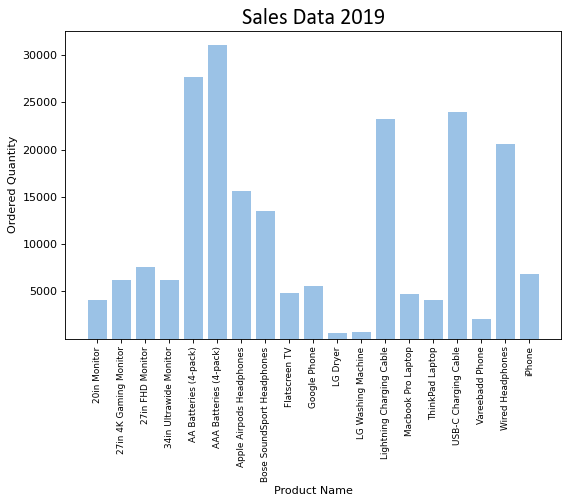

In [9]:
result = all_data[["Quantity Ordered", "Product", "Sales"]].groupby(["Product"]).sum()

products = [product for product, df in all_data.groupby("Product")]
quantity = [i*5000 for i in range(1,7)]

plt.figure(figsize=(8,5), dpi=80)

plt.title("Sales Data 2019", fontdict={"fontname":"Calibri", "fontsize":20})

colors = ["#F4B084", "#A9D08E", "#9BC2E6", "#FFD966"]

plt.bar(products, result["Quantity Ordered"], color=colors[2])

plt.xlabel("Product Name")
plt.ylabel("Ordered Quantity")

plt.xticks(products, rotation="vertical", size=8)
plt.yticks(quantity)

plt.show()

In [ ]:
result_qty = all_data[["Quantity Ordered", "Product", "Sales"]].groupby(["Product"]).sum()
result_prc = all_data[["Price Each", "Product", "Quantity Ordered"]].groupby(["Product"]).mean()

products = result_qty.index.tolist()

fig, ax1 = plt.subplots(figsize=(8,5), dpi=80)
ax2 = ax1.twinx()

ax1.set_title("Sales Data 2019", fontdict={"fontname": "Calibri", "fontsize": 20})

colors = ["#F4B084", "#A9D08E", "#9BC2E6", "#FFD966"]

ax1.bar(products, result_qty["Quantity Ordered"], color=colors[2])
ax2.plot(products, result_prc["Price Each"], color=colors[0])

ax1.set_xlabel("Product Name")
ax1.set_ylabel("Ordered Quantity")
ax2.set_ylabel("Price ($)")

# set_xticks first - calling set_xticklabels on its own is an error in
# current matplotlib unless the locator is already fixed.
ax1.set_xticks(range(len(products)))
ax1.set_xticklabels(products, rotation="vertical", size=8)

plt.show()